# Unconstrained Optimization with GMM

Finding minima and maxima by conditioning on derivatives being zero.

We include derivatives in our training data and condition on them being zero to find stationary points.

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 14:22:45
Initial memory usage: 319.12 MB


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

---
<a id='optimization'></a>
## 3. Optimization with Generative Models

To find minima/maxima, we include derivatives in our data and condition on them being zero.

In [3]:
# Using the same polynomial: y = x^4 - 4x^2 + x + 3
# Derivative: y' = 4x^3 - 8x + 1

x = np.linspace(-2.25, 2, 200)
y = x**4 - 4*x**2 + x + 3
y_prime = 4*x**3 - 8*x + 1

# Find stationary points analytically
stationary_pts = np.roots([4, 0, -8, 1])
print("Stationary points (where y'=0):")
print(stationary_pts)

Stationary points (where y'=0):
[-1.4729976   1.34699741  0.12600019]


In [4]:
# Build GMM with x, y, and y'
data = np.array([x, y, y_prime]).T

gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 13 components


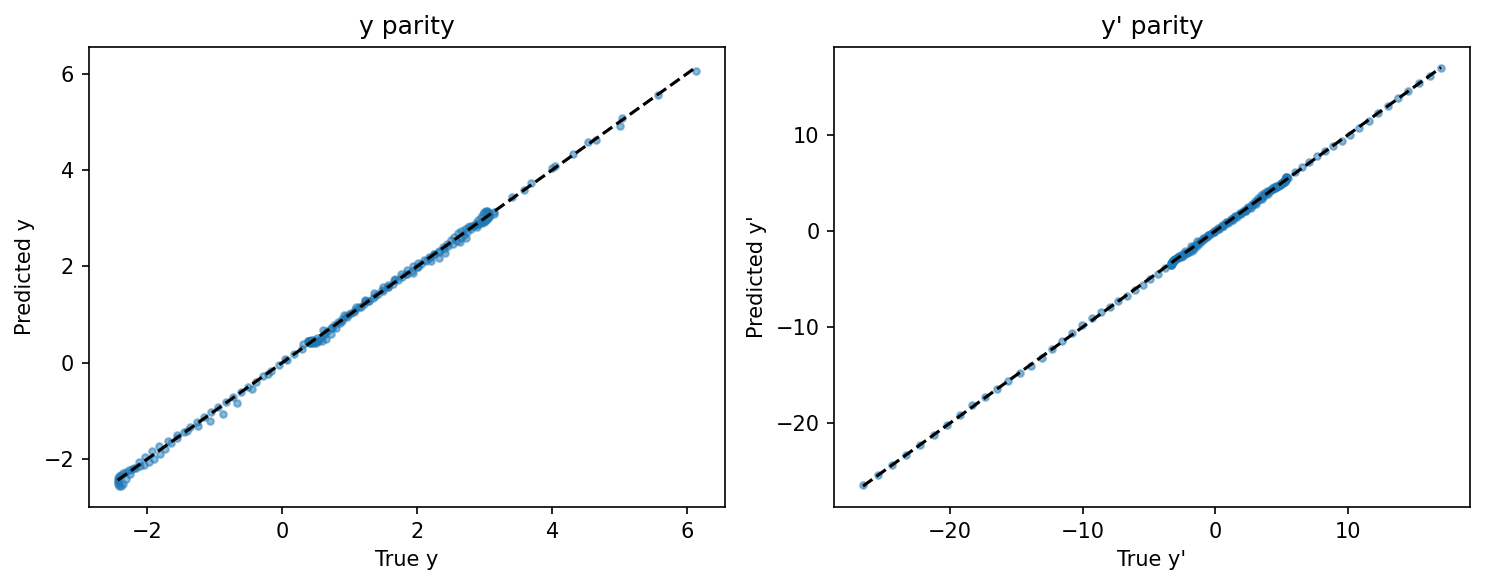

In [5]:
# Validate: condition on x, predict y and y'
pred = gmm.predict([0], data[:, 0:1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data[:, 1], pred[:, 0], alpha=0.5, s=10)
axes[0].plot([data[:, 1].min(), data[:, 1].max()], 
             [data[:, 1].min(), data[:, 1].max()], 'k--')
axes[0].set_xlabel('True y')
axes[0].set_ylabel('Predicted y')
axes[0].set_title('y parity')

axes[1].scatter(data[:, 2], pred[:, 1], alpha=0.5, s=10)
axes[1].plot([data[:, 2].min(), data[:, 2].max()], 
             [data[:, 2].min(), data[:, 2].max()], 'k--')
axes[1].set_xlabel("True y'")
axes[1].set_ylabel("Predicted y'")
axes[1].set_title("y' parity")

plt.tight_layout()
plt.show()

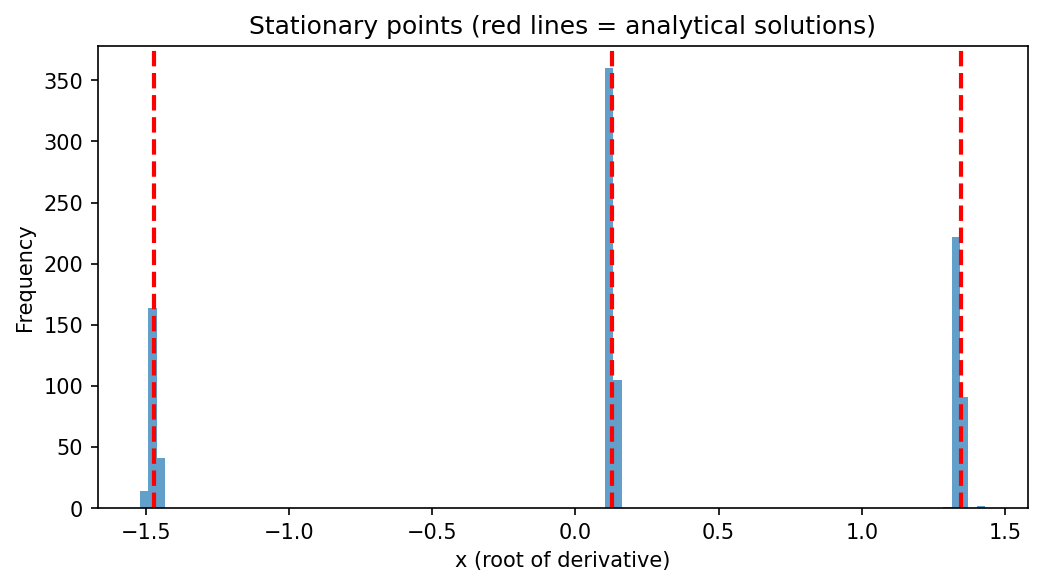

In [6]:
# Find stationary points by conditioning on y'=0
c = gmm.condition([2], [[0.0]])

results = c.sample(1000)

plt.figure(figsize=(8, 4))
plt.hist(results[:, 0], bins=100, alpha=0.7)
plt.xlabel('x (root of derivative)')
plt.ylabel('Frequency')

for r in np.roots([4, 0, -8, 1]):
    plt.axvline(r, c='r', ls='--', lw=2)

plt.title("Stationary points (red lines = analytical solutions)")
plt.show()

In [7]:
# Distinguish minima from maxima using second derivative
# y'' = 12x^2 - 8
# Use sign: +1 if y'' > 0 (minimum), -1 if y'' < 0 (maximum)

y_double_prime_sign = np.where((12 * x**2 - 8) > 0, 1, -1).astype(int)

data = np.array([x, y, y_prime, y_double_prime_sign]).T

gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 10 components


Maximum (y'=0, y''<0):
  0:   0.1280 +/- 0.0022 (n=100)


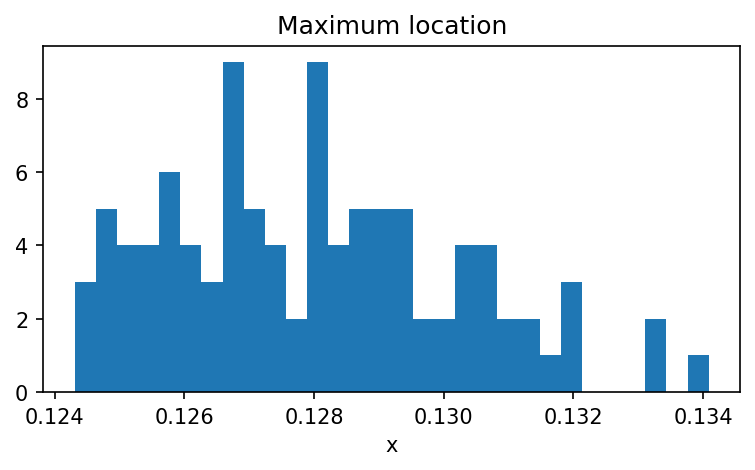

In [8]:
# Find maximum: condition on y'=0 AND y''<0 (sign=-1)
c = gmm.condition([2, 3], [[0.0, -1]])

results = c.sample(100)
print("Maximum (y'=0, y''<0):")
cluster_stats(results[:, 0])

plt.figure(figsize=(6, 3))
plt.hist(results[:, 0], bins=30)
plt.xlabel('x')
plt.title('Maximum location')
plt.show()

Minima (y'=0, y''>0):
  0:  -1.4613 +/- 0.0167 (n=59)
  1:   1.3379 +/- 0.0108 (n=41)


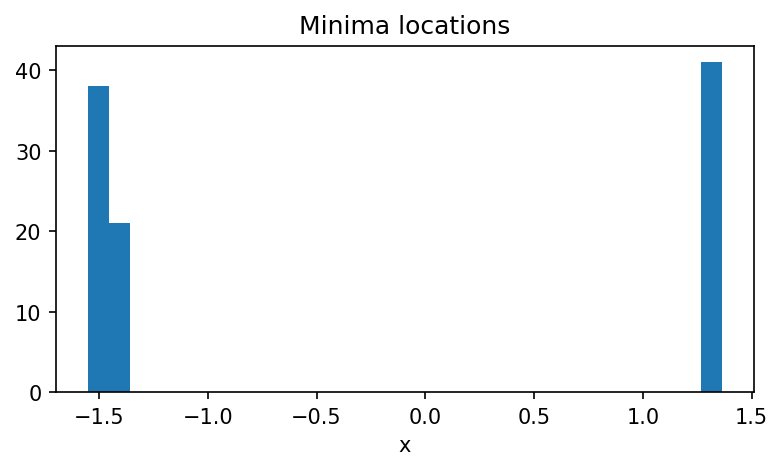

In [9]:
# Find minima: condition on y'=0 AND y''>0 (sign=+1)
c = gmm.condition([2, 3], [[0.0, 1]])

results = c.sample(100)
print("Minima (y'=0, y''>0):")
cluster_stats(results[:, 0])

plt.figure(figsize=(6, 3))
plt.hist(results[:, 0], bins=30)
plt.xlabel('x')
plt.title('Minima locations')
plt.show()

---
## Chemical Engineering Example: Maximizing Intermediate Product

Consider consecutive reactions A → B → C in a batch reactor, where B is the desired product.

**Problem:** Find optimal residence time τ to maximize concentration of intermediate B.

For first-order consecutive reactions with rate constants k₁ and k₂:

$$C_B(\tau) = \frac{C_{A0} k_1}{k_2 - k_1} \left(e^{-k_1\tau} - e^{-k_2\tau}\right)$$

$$\frac{dC_B}{d\tau} = C_{A0} k_1 \frac{k_2 e^{-k_2\tau} - k_1 e^{-k_1\tau}}{k_2 - k_1}$$

**Analytical optimum:** $\tau^* = \frac{\ln(k_1/k_2)}{k_1 - k_2}$

Consecutive Reactions: A -> B -> C
Rate constants: k1=0.5 min^-1, k2=0.2 min^-1

Analytical optimum:
  Optimal residence time: τ* = 3.054 min
  Maximum CB concentration: 0.5429 mol/L


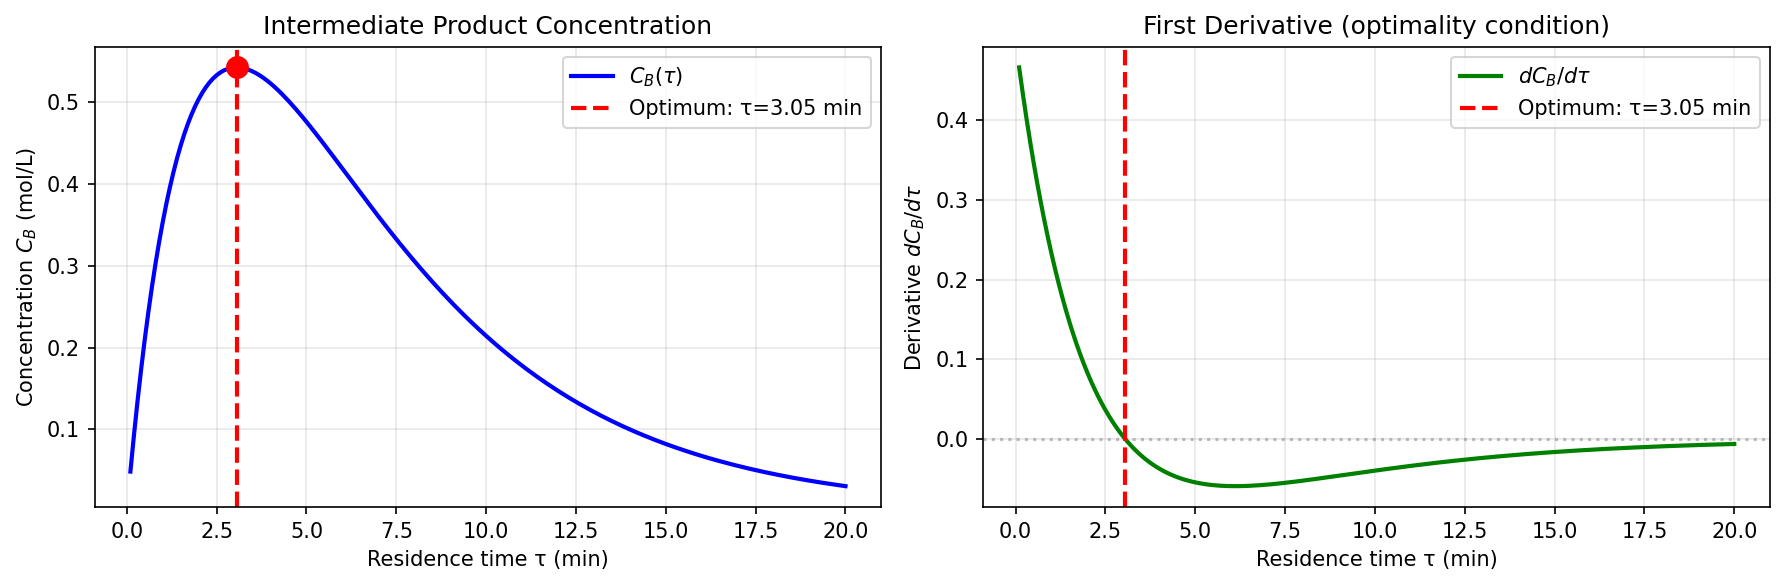

In [10]:
# Consecutive reactions: A -> B -> C
# Parameters
k1 = 0.5  # min^-1 (A -> B)
k2 = 0.2  # min^-1 (B -> C)
CA0 = 1.0  # mol/L (initial concentration of A)

# Generate data
tau = np.linspace(0.1, 20, 200)  # residence time (min)

# Concentration of B
CB = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau) - np.exp(-k2 * tau))

# Derivative dCB/dtau
dCB_dtau = CA0 * k1 * (k2 * np.exp(-k2 * tau) - k1 * np.exp(-k1 * tau)) / (k2 - k1)

# Second derivative (for distinguishing max from inflection points)
d2CB_dtau2 = CA0 * k1 * (-k2**2 * np.exp(-k2 * tau) + k1**2 * np.exp(-k1 * tau)) / (k2 - k1)

# Analytical optimum
tau_opt_analytical = np.log(k1 / k2) / (k1 - k2)
CB_max_analytical = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_opt_analytical) - np.exp(-k2 * tau_opt_analytical))

print(f"Consecutive Reactions: A -> B -> C")
print(f"Rate constants: k1={k1} min^-1, k2={k2} min^-1")
print(f"\nAnalytical optimum:")
print(f"  Optimal residence time: τ* = {tau_opt_analytical:.3f} min")
print(f"  Maximum CB concentration: {CB_max_analytical:.4f} mol/L")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: CB vs tau
axes[0].plot(tau, CB, 'b-', lw=2, label='$C_B(\\tau)$')
axes[0].axvline(tau_opt_analytical, color='r', ls='--', lw=2, label=f'Optimum: τ={tau_opt_analytical:.2f} min')
axes[0].plot(tau_opt_analytical, CB_max_analytical, 'ro', ms=10, zorder=5)
axes[0].set_xlabel('Residence time τ (min)')
axes[0].set_ylabel('Concentration $C_B$ (mol/L)')
axes[0].set_title('Intermediate Product Concentration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Derivative
axes[1].plot(tau, dCB_dtau, 'g-', lw=2, label="$dC_B/d\\tau$")
axes[1].axhline(0, color='gray', ls=':', alpha=0.5)
axes[1].axvline(tau_opt_analytical, color='r', ls='--', lw=2, label=f'Optimum: τ={tau_opt_analytical:.2f} min')
axes[1].set_xlabel('Residence time τ (min)')
axes[1].set_ylabel('Derivative $dC_B/d\\tau$')
axes[1].set_title('First Derivative (optimality condition)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Best model: 10 components


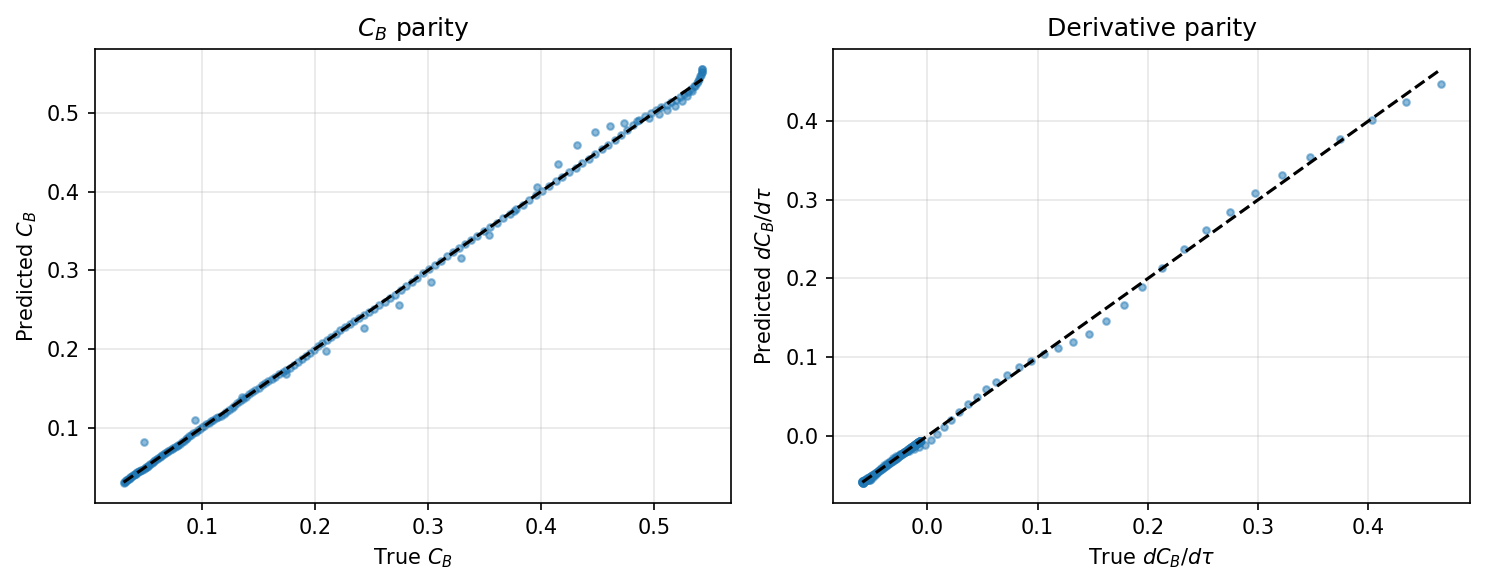

In [11]:
# Build GMM with τ, CB, and dCB/dτ
data_rxn = np.array([tau, CB, dCB_dtau]).T

gmm_rxn, info_rxn = best_gmm(data_rxn, verbose=False)
print(f"Best model: {info_rxn['best_k']} components")

# Validate the model
pred = gmm_rxn.predict([0], data_rxn[:, 0:1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data_rxn[:, 1], pred[:, 0], alpha=0.5, s=10)
axes[0].plot([data_rxn[:, 1].min(), data_rxn[:, 1].max()], 
             [data_rxn[:, 1].min(), data_rxn[:, 1].max()], 'k--')
axes[0].set_xlabel('True $C_B$')
axes[0].set_ylabel('Predicted $C_B$')
axes[0].set_title('$C_B$ parity')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(data_rxn[:, 2], pred[:, 1], alpha=0.5, s=10)
axes[1].plot([data_rxn[:, 2].min(), data_rxn[:, 2].max()], 
             [data_rxn[:, 2].min(), data_rxn[:, 2].max()], 'k--')
axes[1].set_xlabel("True $dC_B/d\\tau$")
axes[1].set_ylabel("Predicted $dC_B/d\\tau$")
axes[1].set_title("Derivative parity")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

GMM Optimization Results:
  Analytical optimum: τ* = 3.054 min
  GMM mean: 2.891 ± 0.104 min
  GMM median: 2.902 min
  0:   2.8909 +/- 0.1043 (n=1000)


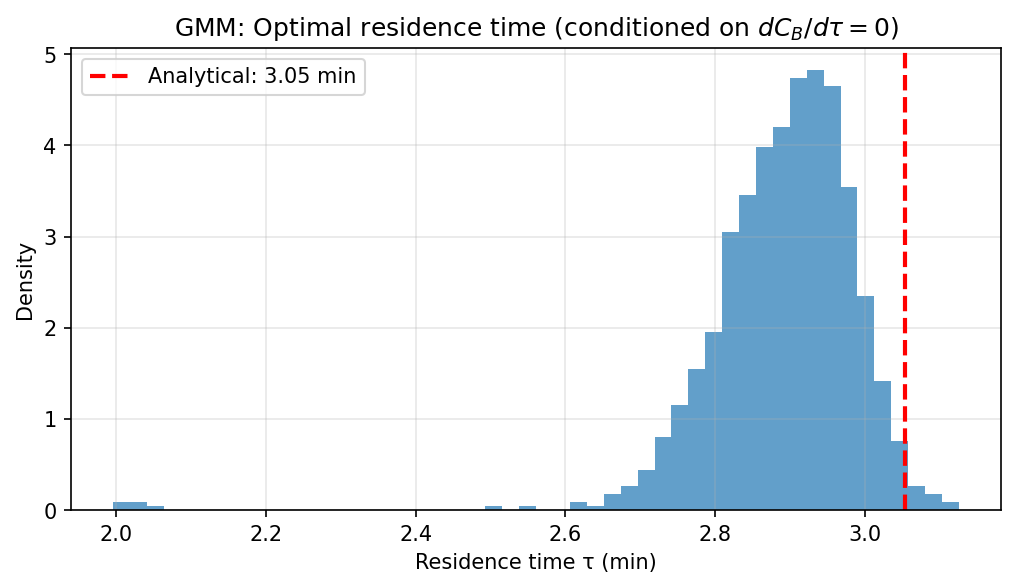

In [12]:
# Find optimum by conditioning on dCB/dτ = 0
c_rxn = gmm_rxn.condition([2], [[0.0]])
results_rxn = c_rxn.sample(1000)

print(f"GMM Optimization Results:")
print(f"  Analytical optimum: τ* = {tau_opt_analytical:.3f} min")
print(f"  GMM mean: {results_rxn[:, 0].mean():.3f} ± {results_rxn[:, 0].std():.3f} min")
print(f"  GMM median: {np.median(results_rxn[:, 0]):.3f} min")

cluster_stats(results_rxn[:, 0])

# Visualize
plt.figure(figsize=(8, 4))
plt.hist(results_rxn[:, 0], bins=50, alpha=0.7, density=True)
plt.axvline(tau_opt_analytical, c='r', ls='--', lw=2, label=f'Analytical: {tau_opt_analytical:.2f} min')
plt.xlabel('Residence time τ (min)')
plt.ylabel('Density')
plt.title('GMM: Optimal residence time (conditioned on $dC_B/d\\tau = 0$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Summary: Consecutive Reactions Optimization

The GMM successfully identifies the optimal residence time to maximize intermediate product B concentration by conditioning on the derivative being zero. This demonstrates the approach on a realistic chemical engineering problem where:

- **Too short residence time:** Insufficient conversion of A to B
- **Too long residence time:** Excessive conversion of B to C
- **Optimal point:** Balances formation and consumption of B

The generative model learns the relationship between τ, C_B, and dC_B/dτ from training data, then identifies the optimum by sampling from the conditional distribution P(τ | dC_B/dτ = 0).

In [13]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 14:22:45
End time:        2025-12-18 14:22:47
Elapsed time:    1.79 seconds (0.03 minutes)
----------------------------------------------------------------------
Initial memory:  319.12 MB
Final memory:    419.83 MB
Memory change:   +100.70 MB
